<a href="https://colab.research.google.com/github/springboardmentor123g/PlantDocBotProject/blob/Intern-UjjwalKumar/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from PIL import Image
import os
import random

In [2]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".." + path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_path = path + "/train"
valid_path = path + "/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Grape___Esca_(Black_Measles)
256
256


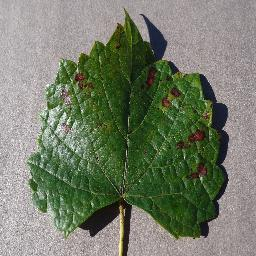

In [3]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
random_class_name = random.choice(classes)
random_class_path = os.path.join(train_path, random_class_name)
random_image_name = random.choice(os.listdir(random_class_path))
random_image_path = os.path.join(random_class_path, random_image_name)

img = Image.open(random_image_path)
print(random_class_name)
print(img.width)
print(img.height)
img

In [4]:
!nvidia-smi

Wed Nov 26 12:25:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch

In [6]:
# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
random_image = torch.rand(3, 256, 256)
random_image

tensor([[[0.7705, 0.9557, 0.2641,  ..., 0.7937, 0.3281, 0.9165],
         [0.0212, 0.3247, 0.9784,  ..., 0.0018, 0.6798, 0.4728],
         [0.3370, 0.9828, 0.3471,  ..., 0.3701, 0.9219, 0.5741],
         ...,
         [0.5888, 0.6383, 0.8514,  ..., 0.9326, 0.9255, 0.2028],
         [0.7563, 0.6056, 0.4689,  ..., 0.6571, 0.2749, 0.1305],
         [0.1633, 0.4512, 0.7364,  ..., 0.1392, 0.7440, 0.7258]],

        [[0.9814, 0.0015, 0.5737,  ..., 0.1510, 0.1692, 0.0301],
         [0.5294, 0.1700, 0.1903,  ..., 0.9451, 0.5908, 0.1226],
         [0.2836, 0.0296, 0.9829,  ..., 0.1353, 0.3236, 0.6621],
         ...,
         [0.9041, 0.3382, 0.8158,  ..., 0.2770, 0.9120, 0.7958],
         [0.6307, 0.6768, 0.7753,  ..., 0.0025, 0.0686, 0.1501],
         [0.3591, 0.8259, 0.9603,  ..., 0.3154, 0.2364, 0.7783]],

        [[0.1501, 0.2849, 0.7386,  ..., 0.2816, 0.3520, 0.0746],
         [0.4570, 0.3244, 0.1142,  ..., 0.9745, 0.3636, 0.4117],
         [0.0341, 0.7407, 0.6190,  ..., 0.8479, 0.5935, 0.

In [8]:
random_image.device

device(type='cpu')

In [9]:
random_image.cpu()

tensor([[[0.7705, 0.9557, 0.2641,  ..., 0.7937, 0.3281, 0.9165],
         [0.0212, 0.3247, 0.9784,  ..., 0.0018, 0.6798, 0.4728],
         [0.3370, 0.9828, 0.3471,  ..., 0.3701, 0.9219, 0.5741],
         ...,
         [0.5888, 0.6383, 0.8514,  ..., 0.9326, 0.9255, 0.2028],
         [0.7563, 0.6056, 0.4689,  ..., 0.6571, 0.2749, 0.1305],
         [0.1633, 0.4512, 0.7364,  ..., 0.1392, 0.7440, 0.7258]],

        [[0.9814, 0.0015, 0.5737,  ..., 0.1510, 0.1692, 0.0301],
         [0.5294, 0.1700, 0.1903,  ..., 0.9451, 0.5908, 0.1226],
         [0.2836, 0.0296, 0.9829,  ..., 0.1353, 0.3236, 0.6621],
         ...,
         [0.9041, 0.3382, 0.8158,  ..., 0.2770, 0.9120, 0.7958],
         [0.6307, 0.6768, 0.7753,  ..., 0.0025, 0.0686, 0.1501],
         [0.3591, 0.8259, 0.9603,  ..., 0.3154, 0.2364, 0.7783]],

        [[0.1501, 0.2849, 0.7386,  ..., 0.2816, 0.3520, 0.0746],
         [0.4570, 0.3244, 0.1142,  ..., 0.9745, 0.3636, 0.4117],
         [0.0341, 0.7407, 0.6190,  ..., 0.8479, 0.5935, 0.

In [10]:
# torch.matmul()
torch.max(random_image) #random_image is a single tensor, you cannot directly use torch.matmul(random_image) because torch.matmul requires two tensors.

tensor(1.0000)

In [11]:
# How to create a pytorch model and how to write a training loop
# We will be subclassing nn.Module.

In [12]:
import torch
import torch.nn as nn

In [13]:
#y=mX + c

In [14]:
weight, bias = 0.5, 0.4

In [15]:
X = torch.arange(0, 2, 0.02)
y = weight * X + bias

In [16]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  def forward(self, x):
    return (self.weights * x) + self.bias

In [17]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [18]:
torch.manual_seed(42)
model=SampleModel()

In [19]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [20]:
from matplotlib import pyplot as plt

In [26]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c="b")
  plt.scatter(X_test, y_test, c="g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")


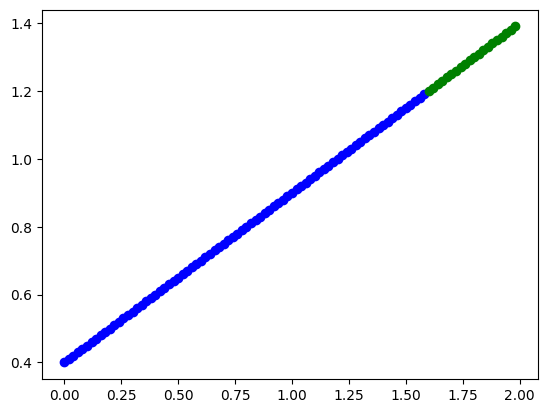

In [27]:
plot_predictions(X_train, y_train, X_test, y_test)

In [28]:
with torch.inference_mode():
  y_preds = model(X_test)

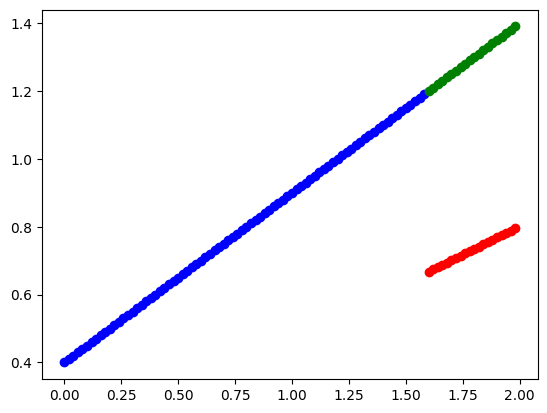

In [29]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [30]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(model.parameters(), lr=0.0001)

In [31]:
# perform the foward pass
# calculate the loss
# backpropagation
# update gradient

In [77]:
torch.manual_seed(42)
EPOCHS = 100
for epochs in range(EPOCHS):
  model.train()
  y_preds=model(X_train)
  loss=loss_fn(y_preds, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    y_test_preds=model(X_test)
    test_loss=loss_fn(y_test_preds, y_test)

  if epochs % 10 == 0:
    print(f"epoch: {epochs} | loss: {loss} | test_loss: {test_loss}")

epoch: 0 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 10 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 20 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 30 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 40 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 50 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 60 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 70 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 80 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918
epoch: 90 | loss: 0.0001004777877824381 | test_loss: 0.00010905861563514918


In [78]:
with torch.inference_mode():
  y_preds = model(X_test)

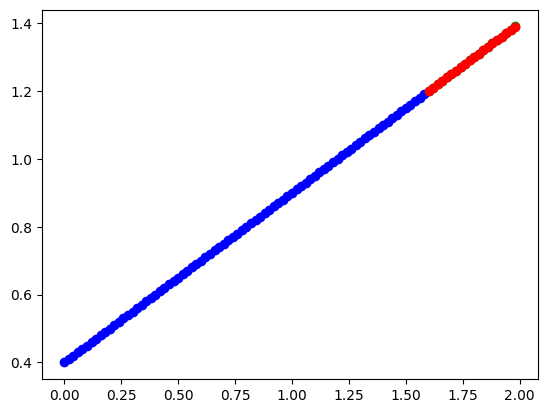

In [79]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [80]:
model.state_dict()

OrderedDict([('weights', tensor([0.5000])), ('bias', tensor([0.3999]))])

In [81]:
len(classes)

38

In [82]:
#from torch.utils.data we need Dataset, Dataloader

In [83]:
#from torchvision we need transforms, datasets

In [84]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models

In [85]:
dummy_transform = transforms.Compose([
    transforms.ToTensor()
])

In [86]:
type(dummy_transform)

torchvision.transforms.transforms.Compose

In [87]:
train_dataset = datasets.ImageFolder(train_path, transform=dummy_transform)


In [88]:
valid_dataset = datasets.ImageFolder(valid_path, transform=None)

In [89]:
print(type(valid_dataset))

<class 'torchvision.datasets.folder.ImageFolder'>


In [90]:
len(train_dataset),len(valid_dataset)

(70295, 17572)

In [91]:
transformed_img = dummy_transform(img)
transformed_img

tensor([[[0.6902, 0.6980, 0.6627,  ..., 0.6039, 0.6157, 0.5608],
         [0.7098, 0.7137, 0.6784,  ..., 0.5961, 0.6157, 0.5882],
         [0.7255, 0.7294, 0.6902,  ..., 0.5725, 0.6118, 0.6078],
         ...,
         [0.8118, 0.6118, 0.7020,  ..., 0.5490, 0.5882, 0.6078],
         [0.5451, 0.7059, 0.7216,  ..., 0.5922, 0.5137, 0.5765],
         [0.9137, 0.8314, 0.6902,  ..., 0.4824, 0.5647, 0.6549]],

        [[0.6745, 0.6824, 0.6471,  ..., 0.5804, 0.5922, 0.5373],
         [0.6941, 0.6980, 0.6627,  ..., 0.5725, 0.5922, 0.5647],
         [0.7098, 0.7137, 0.6745,  ..., 0.5490, 0.5882, 0.5843],
         ...,
         [0.7961, 0.5961, 0.6863,  ..., 0.5098, 0.5490, 0.5686],
         [0.5294, 0.6902, 0.7059,  ..., 0.5529, 0.4745, 0.5373],
         [0.8980, 0.8157, 0.6745,  ..., 0.4431, 0.5255, 0.6157]],

        [[0.6784, 0.6863, 0.6510,  ..., 0.5882, 0.6000, 0.5451],
         [0.6980, 0.7020, 0.6667,  ..., 0.5804, 0.6000, 0.5725],
         [0.7137, 0.7176, 0.6784,  ..., 0.5569, 0.5961, 0.

In [92]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

In [93]:
len(train_dataloader), len(valid_dataloader)

(2197, 550)

In [95]:
def compute_mean_std(dataset, batch_size=32, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
  channel_sum = torch.zeros(3, device=device)
  channel_sqsum = torch.zeros(3, device=device)
  pixel_count = 0

  for x, _ in loader:
    x = x.to(device)
    b, c, h, w = x.shape
    pixel_count+= h * w * b
    channel_sum += x.sum(dim=[0, 2, 3])
    channel_sqsum += (x**2).sum(dim=[0, 2, 3])

  mean = channel_sum / pixel_count
  std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
  return  mean, std

In [96]:
mean, std = compute_mean_std(train_dataset)
mean, std

(tensor([0.4757, 0.5001, 0.4264], device='cuda:0'),
 tensor([0.2165, 0.1957, 0.2320], device='cuda:0'))

In [97]:
mean.tolist(), std.tolist()

([0.47568196058273315, 0.5001007318496704, 0.42636263370513916],
 [0.21649622917175293, 0.19567890465259552, 0.23202040791511536])

In [98]:
mean = [0.47568196058273315, 0.5001007318496704, 0.42636263370513916]
std =  [0.21649622917175293, 0.19567890465259552, 0.23202040791511536]

In [99]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [100]:
valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [101]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=valid_path, transform=valid_transform)

In [102]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle = False, num_workers=2)